# Answers week 7

* Red text: session quiz question
* Cell with code open: needs to be checked by TA
* Missing numbers: coursework questions

#### <span style="color:red"> *Question 7.1*

In [25]:
import numpy as np
from numpy import linalg as la

A = np.array([1,2,3,0,-4,1,0,3,-1]).reshape(3,3)

det_A = la.det(A)
print(f"The determinant of A is: {det_A}")

# x = inv(matrix)@b, where inv(matrix) = A
b = np.array([2,2,-1]).reshape(3,1)  # Reshape into column vector
xyz = A@b
print(f"\nThe solution (x,y,z) of the set of equations is: {xyz.reshape(1,3)}")  # Reshape solution as column vector

# Orthogonal if A@A^T = I
print(f"\nMatrix A:\n{A}")
print(f"Matrix A transposed:\n{A.T}")
print(f"\nA.AT should be the identity matrix:\n{A@A.T}\n{A@A.T == np.identity(3)}")
print(f"\nAlternatively: the inverse of A:\n{la.inv(A)}")
print(f"\nshould be equal to the transpose:\n{A.T}")
print(f"\nwhich is not the case, so A is not orthogonal.")

# A@v = lambda@v
values, v = la.eig(A)
print(f"\nThe Eigenvalues of A are: {values}, \nwith Eigenvectors: \n{v}")

The determinant of A is: 1.0

The solution (x,y,z) of the set of equations is: [[ 3 -9  7]]

Matrix A:
[[ 1  2  3]
 [ 0 -4  1]
 [ 0  3 -1]]
Matrix A transposed:
[[ 1  0  0]
 [ 2 -4  3]
 [ 3  1 -1]]

A.AT should be the identity matrix:
[[ 14  -5   3]
 [ -5  17 -13]
 [  3 -13  10]]
[[False False False]
 [False False False]
 [False False False]]

Alternatively: the inverse of A:
[[ 1. 11. 14.]
 [-0. -1. -1.]
 [-0. -3. -4.]]

should be equal to the transpose:
[[ 1  0  0]
 [ 2 -4  3]
 [ 3  1 -1]]

which is not the case, so A is not orthogonal.

The Eigenvalues of A are: [ 1.         -4.79128785 -0.20871215], 
with Eigenvectors: 
[[ 1.         -0.05055961  0.94256676]
 [ 0.         -0.78318743 -0.08518794]
 [ 0.          0.6197267  -0.32297201]]


#### *Question 7.2*

In [29]:
import numpy as np
from numpy import linalg as la
from math import radians, sin, cos

angle = float(input("Enter the angle: "))

def Ex(angle):
    angle_rad = radians(angle)
    matrix_x = np.array([1,0,0,0,cos(angle_rad),sin(angle_rad),0,-sin(angle_rad),cos(angle_rad)]).reshape(3,3)
    return matrix_x

def Ey(angle):
    angle_rad = radians(angle)
    matrix_y = np.array([cos(angle_rad),0,-sin(angle_rad),0,1,0,sin(angle_rad),0,cos(angle_rad)]).reshape(3,3)
    return matrix_y

def Ez(angle):
    angle_rad = radians(angle)
    matrix_z = np.array([cos(angle_rad),sin(angle_rad),0,-sin(angle_rad),cos(angle_rad),0,0,0,1]).reshape(3,3)
    return matrix_z

print(f"\nEx({angle})=\n{Ex(angle)}")
print(f"\nEy({angle})=\n{Ey(angle)}")
print(f"\nEz({angle})=\n{Ez(angle)}")

Enter the angle:  33



Ex(33.0)=
[[ 1.          0.          0.        ]
 [ 0.          0.83867057  0.54463904]
 [ 0.         -0.54463904  0.83867057]]

Ey(33.0)=
[[ 0.83867057  0.         -0.54463904]
 [ 0.          1.          0.        ]
 [ 0.54463904  0.          0.83867057]]

Ez(33.0)=
[[ 0.83867057  0.54463904  0.        ]
 [-0.54463904  0.83867057  0.        ]
 [ 0.          0.          1.        ]]


#### <span style="color:red"> *Question 7.3*

In [57]:
import numpy as np
from numpy import linalg as la
from math import radians, sin, cos

example_E = np.array([-0.06698874,-0.87275577,-0.48353891,0.49272847,-0.45034696,0.74458463,-0.86760081,-0.1883746,0.46019978]).reshape(3,3)

angle_z = 180-123
angle_y = 90-27.4
angle_z2 = 192.25

def Ey(angle_y):
    """A function for the rotation around the y-axis"""
    rady = radians(angle_y)
    matrix_y = np.array([cos(rady),0,-sin(rady),0,1,0,sin(rady),0,cos(rady)]).reshape(3,3)
    return matrix_y

def Ez(angle_z):
    """A funtion for the rotation around the z-axis"""
    radz = radians(angle_z)
    matrix_z = np.array([cos(radz),sin(radz),0,-sin(radz),cos(radz),0,0,0,1]).reshape(3,3)
    return matrix_z

def Ez2(angle_z2):
    """A function dor the second rotation around the z-axis"""
    radz2 = radians(angle_z2)
    matrix_z2 = np.array([cos(radz2),sin(radz2),0,-sin(radz2),cos(radz2),0,0,0,1]).reshape(3,3)
    return matrix_z2

E = Ez(angle_z)@Ey(angle_y)@Ez2(angle_z2)
print(f"The composed matrix E:\n{E}")
print(f"\nCheck with function allclose() if the given matrix and the composed matrix are equal: {np.allclose(E, example_E)}") # Check if the given matrix and E are equal, including rounding errors.

# Properties of a rotation matrix: A^T = A^-1 and det(A) =1
inv_E = la.inv(E)
trans_E = E.T
det_E = la.det(E)
print(f"\nThe inverse of E:\n{inv_E}\nand the transpose of E:\n{trans_E}")
print(f"\nE is a rotation matrix if E^T = E^-1, which is {np.allclose(trans_E, inv_E)}\nand if the determinant is 1: det(E) = {det_E}")  # Check if the transpose and inverse are equal, including rounding errors.

# Prove at least one Eigenvalue: lambda = 1 for E
lambda_E, v_E = la.eig(E)
print(f"The Eigenvalues of E are:\n{lambda_E}\nThe Eigenvalues contain a value equal to one in the last index: {np.real(lambda_E)}\n")

# Galactic pole coordinates in degrees
RA = 192.25
DEC = 27.4

# Galactic pole coordinates in radians
alpha = radians(RA)
delta = radians(DEC)

x = cos(delta)*cos(alpha)
y = cos(delta)*sin(alpha)
z = sin(delta)

vector_r = np.array([x,y,z])  # Calculate the normalized vector v of the RA and DEC.

v = [-0.86760081, -0.1883746, 0.46019978]  # The given v.
norm_v = la.norm(v)
print(f"v from the equation: {vector_r}\nThe nornalized v = given v is: {np.allclose(vector_r, v)}")
print(f"The norm of v is: {norm_v}")

# Rotate v with E
E_v = E@v
v2 = np.round(E_v)
print(f"\nThe vector v2 is: {v2}, which represents the coordinates of the galactic pole.")

The composed matrix E:
[[-0.06698874 -0.87275577 -0.48353891]
 [ 0.49272847 -0.45034696  0.74458463]
 [-0.86760081 -0.1883746   0.46019978]]

Check with function allclose() if the given matrix and the composed matrix are equal: True

The inverse of E:
[[-0.06698874  0.49272847 -0.86760081]
 [-0.87275577 -0.45034696 -0.1883746 ]
 [-0.48353891  0.74458463  0.46019978]]
and the transpose of E:
[[-0.06698874  0.49272847 -0.86760081]
 [-0.87275577 -0.45034696 -0.1883746 ]
 [-0.48353891  0.74458463  0.46019978]]

E is a rotation matrix if E^T = E^-1, which is True
and if the determinant is 1: det(E) = 1.0
The Eigenvalues of E are:
[-0.52856796+0.84889099j -0.52856796-0.84889099j  1.        +0.j        ]
The Eigenvalues contain a value equal to one in the last index: [-0.52856796 -0.52856796  1.        ]

v from the equation: [-0.86760081 -0.1883746   0.46019978]
The nornalized v = given v is: True
The norm of v is: 0.9999999964749322

The vector v2 is: [ 0. -0.  1.], which represents the coo

#### *Question 7.4*

In [129]:
import numpy as np

x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])
list1 = []

X = float(input("Enter your X value: "))  # Enter an X.

for value in x:
    if value < X:  # Search x for values smaller than X
        x1 = np.max(value)  # Assign the largest of those number as the lower boundary of the interval
        i_1 = np.where(x == x1)[0][0]  # Get the index of the number
    if value > X:
        list1.append(value)

x2 = min(list1)
i_2 = np.where(x == x2)[0][0]

y1 = y[i_1]
y2 = y[i_2]

Y = y1 + ((y2-y1)*(X-x1))/(x2-x1)

print(f"The interpolated value of {X} is: {Y}")
print(f"The interpolated value with a numpy function is: {np.interp(X,x,y)}")


Enter your X value:  2.5


The interpolated value of 2.5 is: 0.5909090909090908
The interpolated value with a numpy function is: 0.5909090909090908


#### <span style="color:red"> *Question 7.5*

[[ 2.18582332e+02]
 [-5.51003146e+02]
 [ 5.65812237e+02]
 [-3.13633556e+02]
 [ 1.04544074e+02]
 [-2.19331360e+01]
 [ 2.91867715e+00]
 [-2.39059756e-01]
 [ 1.09925609e-02]
 [-2.17117476e-04]]


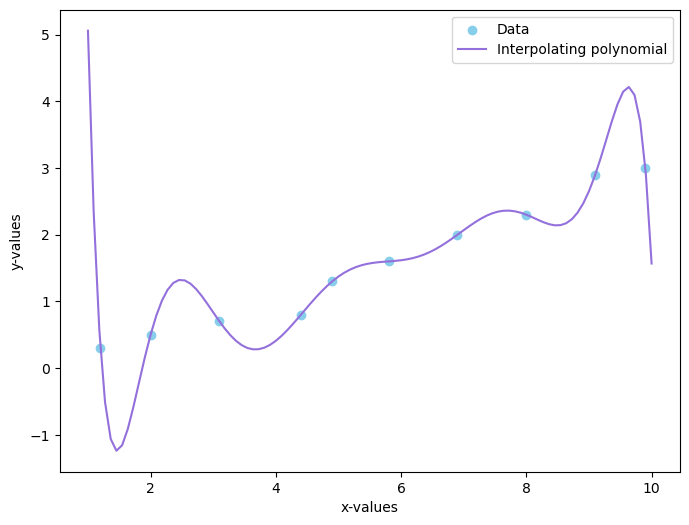

In [7]:
import numpy as np
from numpy.linalg import solve
from matplotlib.pyplot import figure, show

x_data = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y_data = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])

values = []
solution = []
shape = len(y_data)  # The dimension of the matrix A

for i, x in enumerate(x_data):
    f = y_data[i]
    solution.append(f)
    # The polynomial P_n = sum(a_n*x**n)
    for n in range(shape):
        val = x**n
        values.append(float(val))

A = np.array([values]).reshape(shape,shape)  # The matrix of x**n
f_x = np.array([solution]).reshape(shape,1)  # The solutions f in matrix format

a = solve(A,f_x)  # Find the coefficients
print(a)

x2 = np.linspace(1,10,100)

fig = figure(figsize=(8,6))
frame = fig.add_subplot(1,1,1)
frame.scatter(x_data, y_data, color='skyblue', label='Data')
frame.plot(x2, np.polyval(a[::-1],x2), color='mediumpurple', label='Interpolating polynomial')  # Order of the constants: have to start at highest (=last) value.
frame.set_xlabel("x-values")
frame.set_ylabel("y-values")
frame.legend()

show()

#### <span style="color:red"> *Question 7.6*

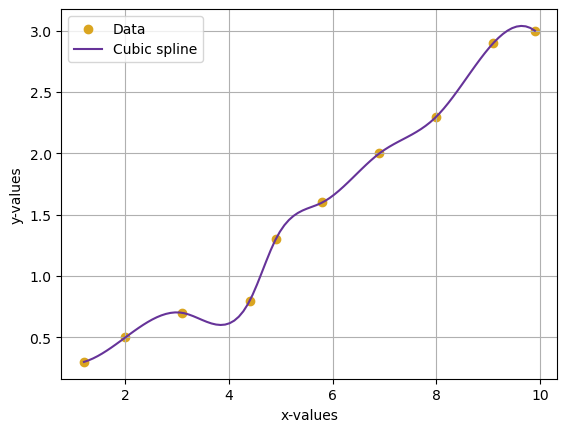

In [15]:
import numpy as np
from matplotlib.pyplot import figure, show
from scipy import interpolate as ip

x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])


f = ip.interp1d(x, y, kind='cubic')

new_x = np.linspace(np.min(x),np.max(x),100)
new_y = f(new_x)

fig = figure()
frame = fig.add_subplot(1,1,1)
frame.scatter(x, y, color='goldenrod', label='Data')
frame.plot(new_x,new_y, color='rebeccapurple', label='Cubic spline')

frame.set_xlabel("x-values")
frame.set_ylabel("y-values")
frame.legend()
frame.grid(True)
show()

The graph made in this question is less 'wobbly' than the one in Question 7.5, it is clearly a better choice for 

#### <span style="color:red"> *Question 7.7*

#### *Question 7.9*

#### <span style="color:red"> *Question 7.10*

#### *Question 7.12*

#### <span style="color:red"> *Question 7.14*